# Train ResNet - Phân loại côn trùng

Notebook huấn luyện **ResNet** (viết từ đầu, không dùng pretrained) trên tập dữ liệu côn trùng 13 lớp.

| Variant | Params | Block |
|---|---|---|
| ResNet-18 | ~11.2M | BasicBlock |
| ResNet-34 | ~21.3M | BasicBlock |
| ResNet-50 | ~23.5M | Bottleneck |
| ResNet-101 | ~42.5M | Bottleneck |

## 1. Khám phá dữ liệu

/var/folders/hg/dtfsyvn54rs5tr074lnfrr7w0000gn/T/ipykernel_74360/56439642.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=split_counts, x="Split", y="Count", palette="viridis", ax=axes[0])
/var/folders/hg/dtfsyvn54rs5tr074lnfrr7w0000gn/T/ipykernel_74360/56439642.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=class_counts, x="Class", y="Count", palette="Set2", ax=axes[1])


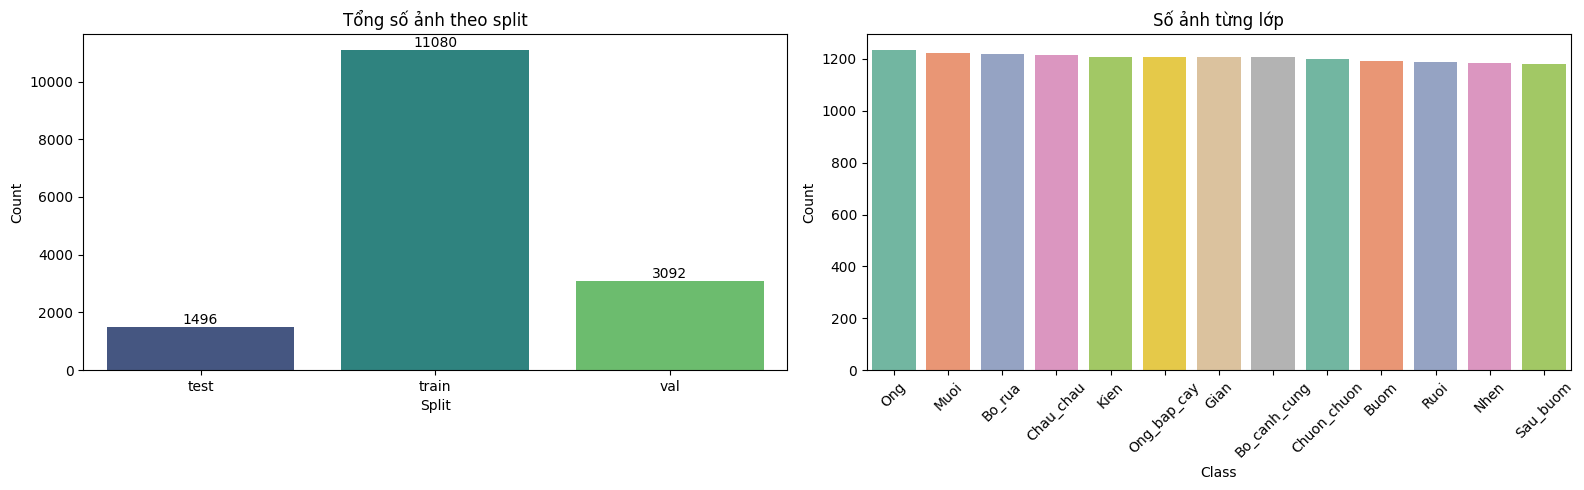

Split
test      1496
train    11080
val       3092


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

dataset_dir = "//Users/nguyenly/Desktop/code/XLA/data/dataset"
splits = ["train", "val", "test"]
data = []

for split in splits:
    split_dir = os.path.join(dataset_dir, split)
    if not os.path.exists(split_dir):
        continue
    for class_name in sorted(os.listdir(split_dir)):
        class_dir = os.path.join(split_dir, class_name)
        if os.path.isdir(class_dir):
            n = len([f for f in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, f))])
            data.append({"Split": split, "Class": class_name, "Count": n})

df = pd.DataFrame(data)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

split_counts = df.groupby("Split")["Count"].sum().reset_index()
sns.barplot(data=split_counts, x="Split", y="Count", palette="viridis", ax=axes[0])
axes[0].set_title("Tổng số ảnh theo split")
for i, row in split_counts.iterrows():
    axes[0].text(i, row.Count, str(int(row.Count)), ha="center", va="bottom")

class_counts = df.groupby("Class")["Count"].sum().reset_index().sort_values("Count", ascending=False)
sns.barplot(data=class_counts, x="Class", y="Count", palette="Set2", ax=axes[1])
axes[1].set_title("Số ảnh từng lớp")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()
print(df.groupby("Split")["Count"].sum().to_string())

## 2. Import & Setup

In [2]:
# Cell 2: Setup path và imports
import sys
import os

# CHỈNH ĐƯỜNG DẪN NÀY cho đúng vị trí project của bạn trong Drive
project_root = "/Users/nguyenly/Desktop/code/XLA"  # <-- sửa tên folder
src_dir = os.path.join(project_root, "src")

# Kiểm tra tồn tại
assert os.path.exists(src_dir), f"Không tìm thấy: {src_dir}"

if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

# Đổi CWD về project root để các đường dẫn tương đối (data, checkpoints...) hoạt động
os.chdir(project_root)
print("CWD:", os.getcwd())
print("src_dir:", src_dir)

import torch
import torch.nn as nn
import torch.optim as optim

from utils import config
from data.preprocess import get_dataloaders
from models.resnet import get_resnet18, get_resnet34, get_resnet50, get_resnet101
from training.evaluate import evaluate_model
from utils.visualize import plot_training_history

print(f"Device  : {config.DEVICE}")
print(f"PyTorch : {torch.__version__}")
print(f"Epochs  : {config.EPOCHS}")
print(f"LR      : {config.LEARNING_RATE}")
print(f"Batch   : {config.BATCH_SIZE}")

CWD: /Users/nguyenly/Desktop/code/XLA
src_dir: /Users/nguyenly/Desktop/code/XLA/src
Device  : mps
PyTorch : 2.11.0
Epochs  : 70
LR      : 0.001
Batch   : 32


## 3. Load dữ liệu

In [3]:

# Load
train_loader, val_loader, test_loader, classes = get_dataloaders()

print(f"\nSố lớp   : {len(classes)}")
print(f"Classes  : {classes}")
print(f"Train    : {len(train_loader)} batches ({len(train_loader.dataset)} ảnh)")
print(f"Val      : {len(val_loader)} batches ({len(val_loader.dataset)} ảnh)")
print(f"Test     : {len(test_loader)} batches ({len(test_loader.dataset)} ảnh)")

Loading data từ: /Users/nguyenly/Desktop/code/XLA/data

Số lớp   : 13
Classes  : ['Bo_canh_cung', 'Bo_rua', 'Buom', 'Chau_chau', 'Chuon_chuon', 'Gian', 'Kien', 'Muoi', 'Nhen', 'Ong', 'Ong_bap_cay', 'Ruoi', 'Sau_buom']
Train    : 346 batches (11080 ảnh)
Val      : 97 batches (3092 ảnh)
Test     : 47 batches (1496 ảnh)


## 4. Khởi tạo mô hình

Đổi `MODEL_NAME` để chọn variant:
- `'resnet18'` — nhẹ nhất, train nhanh
- `'resnet34'` — cân bằng
- `'resnet50'` — mặc định, kết quả tốt nhất
- `'resnet101'` — nặng nhất

In [4]:
MODEL_NAME = "resnet18"   # chọn: resnet18 | resnet34 | resnet50 | resnet101

_model_map = {
    "resnet18":  get_resnet18,
    "resnet34":  get_resnet34,
    "resnet50":  get_resnet50,
    "resnet101": get_resnet101,
}

# Kiểm tra tên model hợp lệ
if MODEL_NAME not in _model_map:
    raise ValueError(f"MODEL_NAME phải là một trong {list(_model_map.keys())}, nhận được: {MODEL_NAME}")

# Kiểm tra biến classes đã tồn tại (từ get_dataloaders)
assert "classes" in dir(), "Biến `classes` chưa được định nghĩa. Hãy chạy cell get_dataloaders trước."
num_classes = len(classes)
print(f"Số lớp        : {num_classes}")
print(f"Danh sách lớp : {classes}")

# Khởi tạo model
model = _model_map[MODEL_NAME](num_classes=num_classes)
model = model.to(config.DEVICE)

# Thống kê tham số
total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - train_params

print(f"\nModel         : {MODEL_NAME.upper()}")
print(f"Device        : {config.DEVICE}")
print(f"Tổng tham số  : {total_params:,}")
print(f"Tham số train : {train_params:,}")
print(f"Tham số đóng băng: {frozen_params:,}")
print(f"Tỷ lệ train  : {train_params/total_params*100:.2f}%")

Số lớp        : 13
Danh sách lớp : ['Bo_canh_cung', 'Bo_rua', 'Buom', 'Chau_chau', 'Chuon_chuon', 'Gian', 'Kien', 'Muoi', 'Nhen', 'Ong', 'Ong_bap_cay', 'Ruoi', 'Sau_buom']

Model         : RESNET18
Device        : mps
Tổng tham số  : 11,183,181
Tham số train : 11,183,181
Tham số đóng băng: 0
Tỷ lệ train  : 100.00%


## 5. Cấu hình Optimizer & Scheduler

In [5]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=1e-4,
    nesterov=True
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=config.EPOCHS,
    eta_min=1e-5
)

models_saved_dir = os.path.join(project_root, "models_saved")
os.makedirs(models_saved_dir, exist_ok=True)
save_path = os.path.join(models_saved_dir, f"best_{MODEL_NAME}.pth")

print(f"Loss      : CrossEntropyLoss (label_smoothing=0.1)")
print(f"Optimizer : SGD (lr=0.01, momentum=0.9, weight_decay=1e-4, nesterov=True)")
print(f"Scheduler : CosineAnnealingLR (T_max={config.EPOCHS}, eta_min=1e-5)")
print(f"Save path : {save_path}")

Loss      : CrossEntropyLoss (label_smoothing=0.1)
Optimizer : SGD (lr=0.01, momentum=0.9, weight_decay=1e-4, nesterov=True)
Scheduler : CosineAnnealingLR (T_max=70, eta_min=1e-5)
Save path : /Users/nguyenly/Desktop/code/XLA/models_saved/best_resnet18.pth


## 6.  huấn luyện

In [6]:
import time

best_val_loss = float("inf")
early_stop_counter = 0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

print(f"Bắt đầu huấn luyện [{MODEL_NAME.upper()}] trên {config.DEVICE.upper()}")
print(f"Train samples: {len(train_loader.dataset)} | Val samples: {len(val_loader.dataset)}")
print(f"Batches/epoch: {len(train_loader)}\n")

for epoch in range(1, config.EPOCHS + 1):
    print(f"Epoch {epoch}/{config.EPOCHS}")
    epoch_start = time.time()

    # ── TRAIN ──────────────────────────────────────────────
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    n_batches = len(train_loader)

    for batch_idx, (inputs, labels) in enumerate(train_loader, 1):
        inputs, labels = inputs.to(config.DEVICE), labels.to(config.DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Progress bar realtime kiểu Keras
        bar_len = 30
        filled = int(bar_len * batch_idx / n_batches)
        bar = "=" * filled + ">" + "." * (bar_len - filled - 1) if filled < bar_len else "=" * bar_len
        cur_loss = running_loss / total
        cur_acc  = correct / total
        elapsed_so_far = time.time() - epoch_start

        print(
            f"\r{batch_idx}/{n_batches} [{bar}] - "
            f"{elapsed_so_far:.0f}s - "
            f"loss: {cur_loss:.4f} - acc: {cur_acc:.4f}",
            end="", flush=True
        )

    train_loss = running_loss / total
    train_acc  = correct / total

    # ── VALIDATION ─────────────────────────────────────────
    model.eval()
    val_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(config.DEVICE), labels.to(config.DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= total
    val_acc   = correct / total
    elapsed = time.time() - epoch_start

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    # In dòng tổng kết epoch (ghi đè lên dòng progress)
    bar = "=" * 30
    print(
        f"\r{n_batches}/{n_batches} [{bar}] - "
        f"{elapsed:.0f}s - "
        f"loss: {train_loss:.4f} - acc: {train_acc:.4f} - "
        f"val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}"
    )

    # ── SAVE & EARLY STOPPING ──────────────────────────────
    if val_loss < best_val_loss:
        prev = best_val_loss
        best_val_loss = val_loss
        early_stop_counter = 0
        torch.save(model.state_dict(), save_path)
        if prev == float("inf"):
            print(f"   val_loss improved from inf to {val_loss:.4f}, saving model to {os.path.basename(save_path)}")
        else:
            print(f"   val_loss improved from {prev:.4f} to {val_loss:.4f}, saving model to {os.path.basename(save_path)}")
    else:
        early_stop_counter += 1
        print(f"   val_loss did not improve from {best_val_loss:.4f} ({early_stop_counter}/{config.EARLY_STOPPING_PATIENCE})")
        if early_stop_counter >= config.EARLY_STOPPING_PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch}")
            break

print(f"\n=== HOÀN TẤT HUẤN LUYỆN ===")
print(f"Best val_loss : {best_val_loss:.4f}")
print(f"Model saved   : {save_path}")

346/346 [==============================] - 49s - loss: 0.7132 - acc: 0.9526

/Users/nguyenly/Desktop/code/XLA/.venv/lib/python3.12/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/Users/nguyenly/Desktop/code/XLA/.venv/lib/python3.12/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


346/346 [==============================] - 81s - loss: 0.7132 - acc: 0.9526 - val_loss: 0.7887 - val_acc: 0.9175
   val_loss did not improve from 0.7842 (4/8)
Epoch 67/70
43/346 [===>..........................] - 9s - loss: 0.6922 - acc: 0.9608

/Users/nguyenly/Desktop/code/XLA/.venv/lib/python3.12/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


51/346 [====>.........................] - 10s - loss: 0.6921 - acc: 0.9602

...

113/346 [=========>....................] - 17s - loss: 0.7014 - acc: 0.9566

/Users/nguyenly/Desktop/code/XLA/.venv/lib/python3.12/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


346/346 [==============================] - 49s - loss: 0.7030 - acc: 0.9542

/Users/nguyenly/Desktop/code/XLA/.venv/lib/python3.12/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/Users/nguyenly/Desktop/code/XLA/.venv/lib/python3.12/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


346/346 [==============================] - 81s - loss: 0.7030 - acc: 0.9542 - val_loss: 0.7744 - val_acc: 0.9259
   val_loss improved from 0.7822 to 0.7744, saving model to best_resnet18.pth

=== HOÀN TẤT HUẤN LUYỆN ===
Best val_loss : 0.7744
Model saved   : /Users/nguyenly/Desktop/code/XLA/models_saved/best_resnet18.pth


## 7. Biểu đồ Loss & Accuracy

[✓] Đã lưu biểu đồ -> /Users/nguyenly/Desktop/code/XLA/models_saved/training_curve_resnet18.png


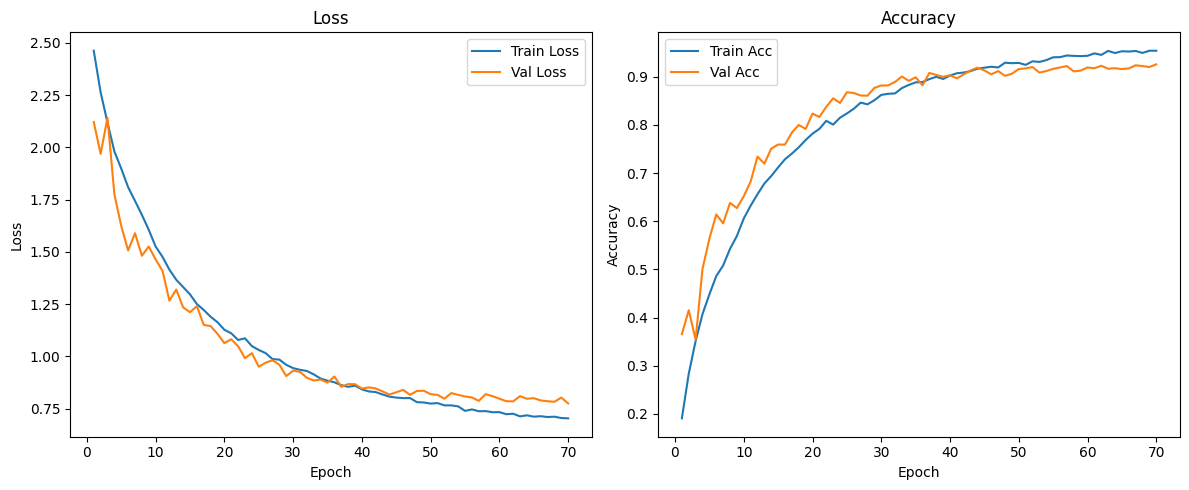

In [7]:
plot_training_history(history, MODEL_NAME, models_saved_dir)

## 8. Đánh giá trên tập Test

In [ ]:
model.load_state_dict(torch.load(save_path, map_location=config.DEVICE))
model = model.to(config.DEVICE)

evaluate_model(model, test_loader, test_loader.dataset, classes, models_saved_dir)

Loading best model từ: /Users/nguyenly/Desktop/code/XLA/models_saved/best_resnet18.pth


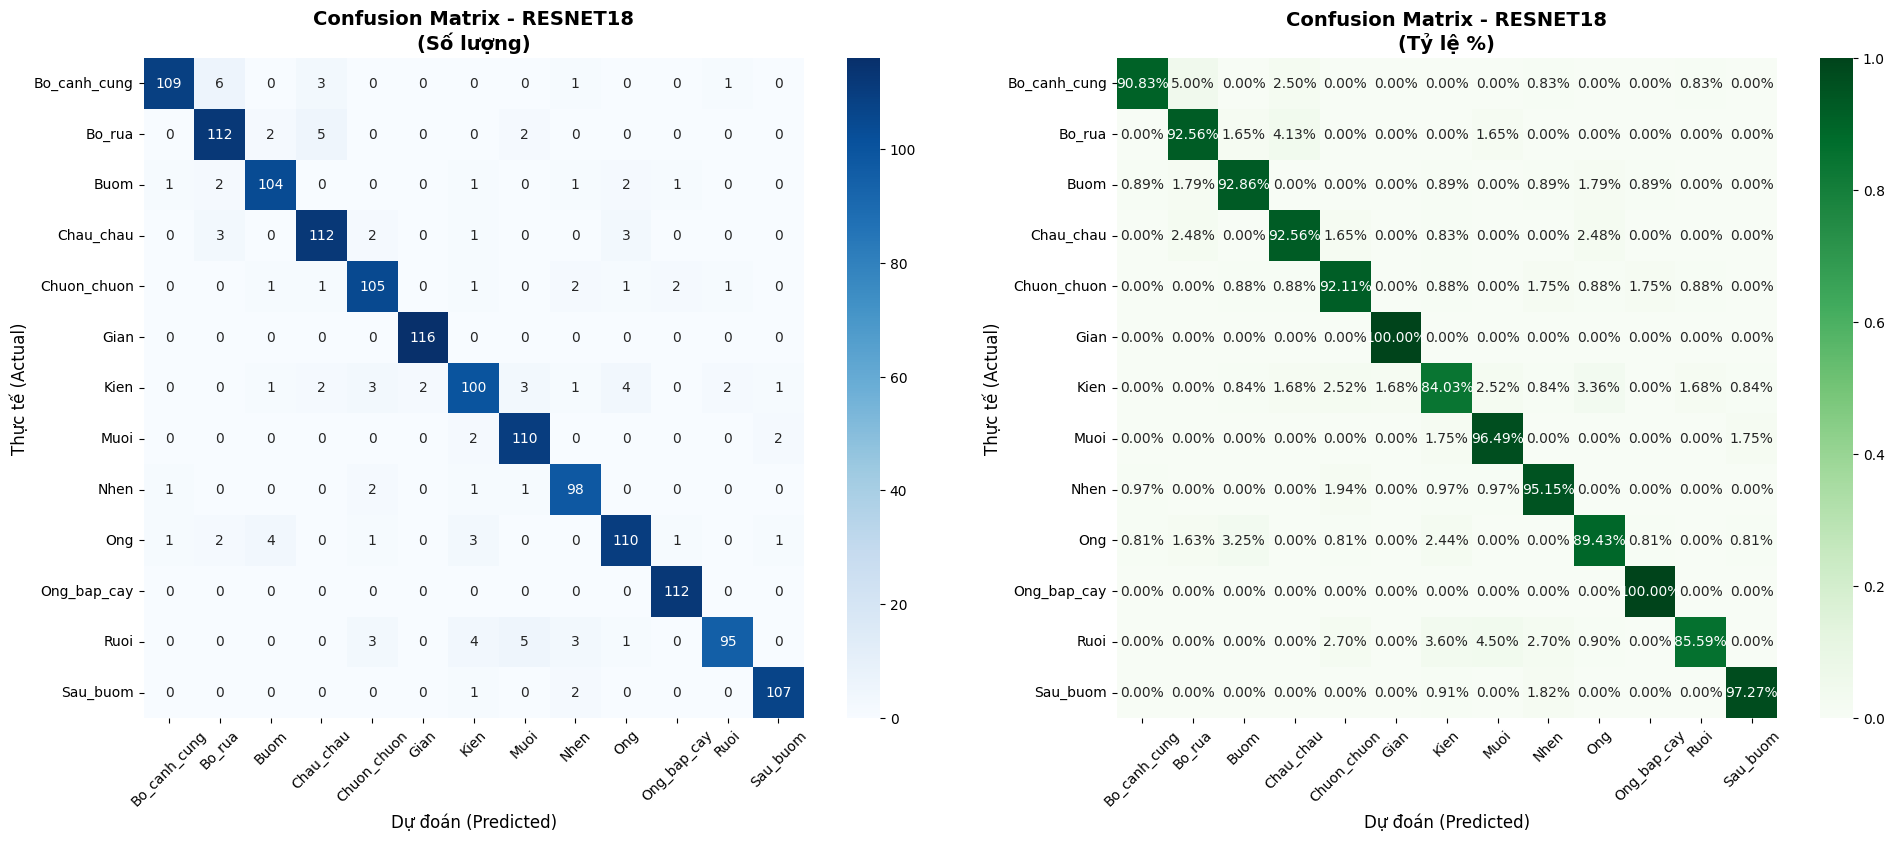


CLASSIFICATION REPORT - RESNET18
              precision    recall  f1-score   support

Bo_canh_cung     0.9732    0.9083    0.9397       120
      Bo_rua     0.8960    0.9256    0.9106       121
        Buom     0.9286    0.9286    0.9286       112
   Chau_chau     0.9106    0.9256    0.9180       121
 Chuon_chuon     0.9052    0.9211    0.9130       114
        Gian     0.9831    1.0000    0.9915       116
        Kien     0.8772    0.8403    0.8584       119
        Muoi     0.9091    0.9649    0.9362       114
        Nhen     0.9074    0.9515    0.9289       103
         Ong     0.9091    0.8943    0.9016       123
 Ong_bap_cay     0.9655    1.0000    0.9825       112
        Ruoi     0.9596    0.8559    0.9048       111
    Sau_buom     0.9640    0.9727    0.9683       110

    accuracy                         0.9291      1496
   macro avg     0.9299    0.9299    0.9294      1496
weighted avg     0.9295    0.9291    0.9288      1496


📊 Test Accuracy: 92.91%
📊 Tổng số mẫu test: 

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import confusion_matrix, classification_report

# ───────────────────────────────────────────────────────────
# 1. LOAD MODEL TỐT NHẤT VÀ DỰ ĐOÁN TRÊN TEST SET
# ───────────────────────────────────────────────────────────
print(f"Loading best model từ: {save_path}")
model.load_state_dict(torch.load(save_path, map_location=config.DEVICE))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(config.DEVICE), labels.to(config.DEVICE)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# ───────────────────────────────────────────────────────────
# 2. TÍNH TOÁN CONFUSION MATRIX
# ───────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)  # chuẩn hóa theo hàng

# ───────────────────────────────────────────────────────────
# 3. VẼ MA TRẬN NHẦM LẪN
# ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# (a) Số lượng tuyệt đối
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=classes, yticklabels=classes,
    cbar=True, square=True, ax=axes[0],
    annot_kws={"size": 10}
)
axes[0].set_title(f'Confusion Matrix - {MODEL_NAME.upper()}\n(Số lượng)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Dự đoán (Predicted)', fontsize=12)
axes[0].set_ylabel('Thực tế (Actual)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# (b) Chuẩn hóa (tỷ lệ %)
sns.heatmap(
    cm_normalized, annot=True, fmt='.2%', cmap='Greens',
    xticklabels=classes, yticklabels=classes,
    cbar=True, square=True, ax=axes[1],
    annot_kws={"size": 10}, vmin=0, vmax=1
)
axes[1].set_title(f'Confusion Matrix - {MODEL_NAME.upper()}\n(Tỷ lệ %)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Dự đoán (Predicted)', fontsize=12)
axes[1].set_ylabel('Thực tế (Actual)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(f'confusion_matrix_{MODEL_NAME}.png', dpi=150, bbox_inches='tight')
plt.show()

# ───────────────────────────────────────────────────────────
# 4. CLASSIFICATION REPORT (Precision, Recall, F1)
# ───────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"CLASSIFICATION REPORT - {MODEL_NAME.upper()}")
print("=" * 70)
print(classification_report(all_labels, all_preds, target_names=classes, digits=4))

# ───────────────────────────────────────────────────────────
# 5. THỐNG KÊ NHANH
# ───────────────────────────────────────────────────────────
accuracy = (all_preds == all_labels).mean()
print(f"\n📊 Test Accuracy: {accuracy*100:.2f}%")
print(f"📊 Tổng số mẫu test: {len(all_labels)}")
print(f"📊 Số mẫu đúng     : {(all_preds == all_labels).sum()}")
print(f"📊 Số mẫu sai      : {(all_preds != all_labels).sum()}")

# Top các cặp lớp bị nhầm nhiều nhất
print("\n🔥 TOP 5 CẶP NHẦM LẪN NHIỀU NHẤT:")
errors = []
for i in range(len(classes)):
    for j in range(len(classes)):
        if i != j and cm[i][j] > 0:
            errors.append((classes[i], classes[j], cm[i][j]))

errors.sort(key=lambda x: x[2], reverse=True)
for actual, predicted, count in errors[:5]:
    print(f"  {actual:20s} → {predicted:20s} : {count} lần")